# Chapitre 8 — Visualisation exploratoire

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Choisir** le type de graphique approprié selon la question et les données
2. **Créer** des visualisations avec Matplotlib et Seaborn
3. **Personnaliser** les graphiques pour une communication efficace
4. **Appliquer** les bonnes pratiques de visualisation (lisibilité, accessibilité)

---

## 8.4 Bonnes pratiques

### Lisibilité

In [ ]:
# Mauvais exemple
plt.plot(x, y)
plt.show()

In [ ]:
# Bon exemple
plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2, color='#2c3e50', marker='o', markersize=6)
plt.title('Évolution des ventes mensuelles', fontsize=14, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Ventes (k€)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

### Accessibilité : les couleurs

In [ ]:
# Palette accessible (daltonisme)
# Éviter : rouge-vert ensemble
# Préférer : bleu-orange, ou utiliser des patterns

# Palette ColorBrewer (testé pour daltonisme)
colors_safe = ['#377eb8', '#ff7f00', '#4daf4a', '#984ea3', '#e41a1c']

# Palette Seaborn accessible
sns.set_palette("colorblind")

---

### Éviter les graphiques trompeurs

In [ ]:
# ❌ MAUVAIS : Axe Y tronqué
plt.figure(figsize=(8, 5))
plt.bar(['A', 'B', 'C'], [98, 99, 100])
plt.ylim(97, 101)  # Exagère les différences !
plt.title('Graphique TROMPEUR')
plt.show()

In [ ]:
# ✅ BON : Axe Y complet
plt.figure(figsize=(8, 5))
plt.bar(['A', 'B', 'C'], [98, 99, 100])
plt.ylim(0, 110)  # Perspective honnête
plt.title('Graphique HONNÊTE')
plt.show()

**Règles d'or :**
- Commencer l'axe Y à 0 pour les bar charts
- Éviter les effets 3D inutiles
- Ne pas utiliser de double axe Y sans justification
- Toujours légender et titrer

---

### Storytelling visuel

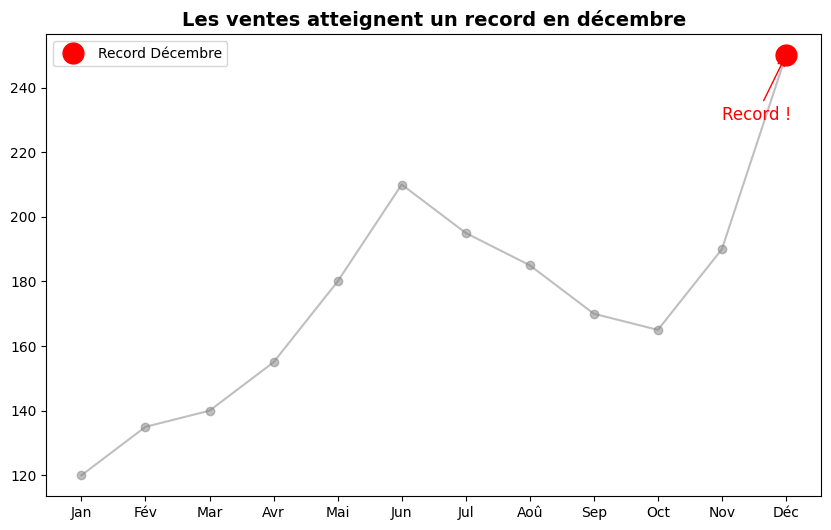

In [15]:
# Mettre en évidence un point clé
mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
ventes = [120, 135, 140, 155, 180, 210, 195, 185, 170, 165, 190, 250]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mois, ventes, 'o-', color='gray', alpha=0.5)
ax.plot(mois[-1], ventes[-1], 'o', color='red', markersize=15, label='Record Décembre')
ax.annotate('Record !', xy=(mois[-1], ventes[-1]), xytext=(10, 230),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, color='red')
ax.set_title('Les ventes atteignent un record en décembre', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

---

### ✍️ Exercice 8.4 : Améliorer un graphique (15 min)

Améliorez ce graphique selon les bonnes pratiques :

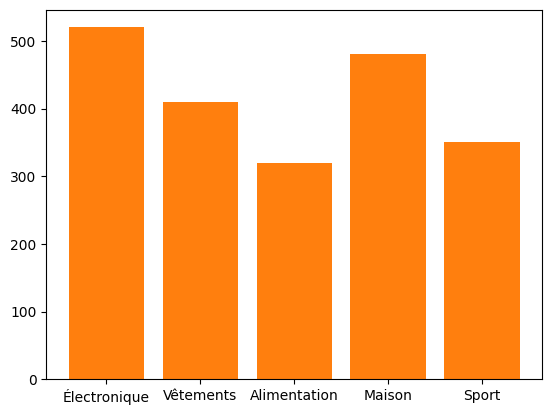

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Données
categories = ['Électronique', 'Vêtements', 'Alimentation', 'Maison', 'Sport']
ventes_2023 = [450, 380, 290, 420, 310]
ventes_2024 = [520, 410, 320, 480, 350]

# Graphique AVANT (à améliorer)
plt.bar(categories, ventes_2023)
plt.bar(categories, ventes_2024)
plt.show()

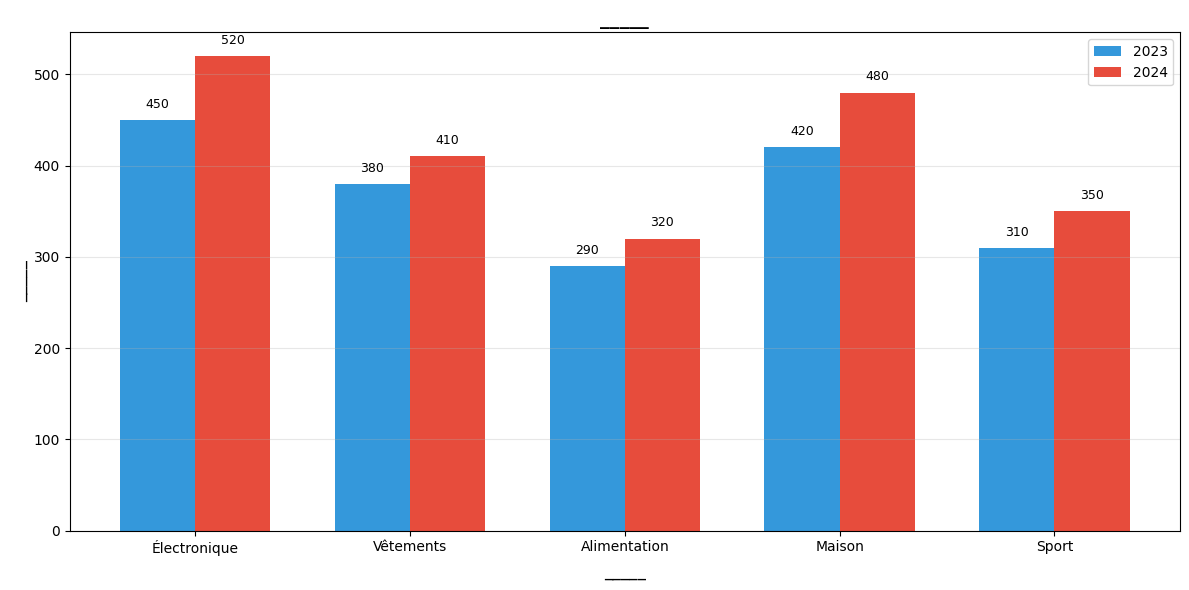

In [17]:
# Graphique APRÈS (votre version améliorée)
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Barres côte à côte
bars1 = ax.bar(x - width/2, ventes_2023, width, label='2023', color='#3498db')
bars2 = ax.bar(x + width/2, ventes_2024, width, label='2024', color='#e74c3c')

# Personnalisation
ax.set_title('_____', fontsize=14, fontweight='bold')
ax.set_xlabel('_____', fontsize=12)
ax.set_ylabel('_____', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Labels sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()